# Imports

In [0]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [0]:
# file location and type
file_location = '../data/raw/Traffic_Volume_Counts_preprocessed.csv'

In [0]:
df = pd.read_csv(file_location)

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42756 entries, 0 to 42755
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   42756 non-null  int64  
 1   SegmentID            42756 non-null  int64  
 2   Roadway Name         42756 non-null  object 
 3   From                 42756 non-null  object 
 4   To                   42756 non-null  object 
 5   Direction            42756 non-null  object 
 6   Date                 42756 non-null  object 
 7   12:00-1:00 AM        42752 non-null  float64
 8   1:00-2:00AM          42752 non-null  float64
 9   2:00-3:00AM          42752 non-null  float64
 10  3:00-4:00AM          42752 non-null  float64
 11  4:00-5:00AM          42752 non-null  float64
 12  5:00-6:00AM          42752 non-null  float64
 13  6:00-7:00AM          42752 non-null  float64
 14  7:00-8:00AM          42752 non-null  float64
 15  8:00-9:00AM          42752 non-null 

In [0]:
df.head(5)

,ID,SegmentID,Roadway Name,From,To,Direction,Date,12:00-1:00 AM,1:00-2:00AM,2:00-3:00AM,3:00-4:00AM,4:00-5:00AM,5:00-6:00AM,6:00-7:00AM,7:00-8:00AM,8:00-9:00AM,9:00-10:00AM,10:00-11:00AM,11:00-12:00PM,12:00-1:00PM,1:00-2:00PM,2:00-3:00PM,3:00-4:00PM,4:00-5:00PM,5:00-6:00PM,6:00-7:00PM,7:00-8:00PM,8:00-9:00PM,9:00-10:00PM,10:00-11:00PM,11:00-12:00AM,Total_Daily_Traffic
0,1,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/09/2012,20.0,10.0,11.0,14.0,13.0,20.0,34.0,66.0,100.0,52.0,68.0,85.0,85.0,94.0,104.0,105.0,147.0,120.0,91.0,83.0,74.0,49.0,42.0,42.0,1529.0
1,2,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/10/2012,21.0,16.0,8.0,6.0,13.0,13.0,31.0,70.0,67.0,45.0,57.0,67.0,73.0,95.0,102.0,98.0,133.0,131.0,95.0,73.0,70.0,63.0,42.0,35.0,1424.0
2,3,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/11/2012,27.0,14.0,6.0,5.0,12.0,16.0,34.0,75.0,69.0,71.0,67.0,70.0,90.0,89.0,115.0,115.0,130.0,143.0,106.0,89.0,68.0,64.0,56.0,43.0,1574.0
3,4,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/12/2012,22.0,7.0,7.0,8.0,11.0,12.0,33.0,75.0,89.0,66.0,70.0,60.0,105.0,103.0,71.0,127.0,122.0,144.0,122.0,76.0,64.0,58.0,64.0,43.0,1559.0
4,5,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/13/2012,31.0,17.0,7.0,5.0,13.0,28.0,29.0,68.0,84.0,64.0,83.0,89.0,88.0,113.0,113.0,126.0,133.0,135.0,102.0,106.0,58.0,58.0,55.0,54.0,1659.0


In [0]:
df.loc[df.isna().any(axis=1)]

,ID,SegmentID,Roadway Name,From,To,Direction,Date,12:00-1:00 AM,1:00-2:00AM,2:00-3:00AM,3:00-4:00AM,4:00-5:00AM,5:00-6:00AM,6:00-7:00AM,7:00-8:00AM,8:00-9:00AM,9:00-10:00AM,10:00-11:00AM,11:00-12:00PM,12:00-1:00PM,1:00-2:00PM,2:00-3:00PM,3:00-4:00PM,4:00-5:00PM,5:00-6:00PM,6:00-7:00PM,7:00-8:00PM,8:00-9:00PM,9:00-10:00PM,10:00-11:00PM,11:00-12:00AM,Total_Daily_Traffic
5,6,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/14/2012,42.0,27.0,21.0,18.0,21.0,13.0,17.0,18.0,46.0,53.0,29.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305.0
11,12,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,SB,01/14/2012,45.0,45.0,28.0,23.0,21.0,19.0,32.0,56.0,67.0,109.0,74.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,519.0
17,18,12809,LITTLE CLOVE ROAD,NORTHERN BOULEVARD,BRISTOL AVENUE,EB,01/14/2012,32.0,31.0,17.0,20.0,9.0,14.0,23.0,50.0,70.0,105.0,127.0,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,595.0
23,24,12809,LITTLE CLOVE ROAD,NORTHERN BOULEVARD,BRISTOL AVENUE,WB,01/14/2012,29.0,27.0,15.0,11.0,6.0,10.0,23.0,36.0,72.0,105.0,164.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,576.0
29,30,14723,NARROWS ROAD SOUTH,HASTINGS STREET,GARSON AVENUE,SB,01/14/2012,44.0,55.0,23.0,10.0,22.0,13.0,24.0,54.0,46.0,61.0,58.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3357,3356,84009,126 STREET,37 AVENUE,38 AVENUE,SB,02/04/2012,57.0,25.0,30.0,34.0,24.0,23.0,36.0,70.0,162.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,461.0
15519,371,156485,23rd Avenue,83th Street,85th Street,EB,02/07/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,369.0,396.0,468.0,465.0,579.0,720.0,491.0,366.0,368.0,322.0,301.0,294.0,286.0,5425.0
15520,371,156485,23rd Avenue,83th Street,85th Street,WB,02/07/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,153.0,167.0,128.0,180.0,189.0,146.0,136.0,126.0,117.0,101.0,75.0,76.0,68.0,1662.0
21538,363,69639,EAST 138 STREET,GRAND CONCOURSE,PARK AVENUE,EB,02/27/2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,428.0,510.0,482.0,563.0,566.0,563.0,614.0,648.0,646.0,713.0,666.0,592.0,514.0,560.0,8065.0


# Data Wrangling and Preprocessing
- Converting data from wide to long format
- dropping unnecessary columns
- making column names more accessible
- Correcting data types

In [0]:
hour_cols = [hour for hour in df.columns if ":" in hour]

In [0]:
df = df.melt(
    id_vars=["ID", "SegmentID","Roadway Name","From","To","Direction","Date"],
    value_vars=hour_cols,
    var_name="hour",
    value_name="traffic_volume"
)

In [0]:
df.head()

,ID,SegmentID,Roadway Name,From,To,Direction,Date,hour,traffic_volume
0,1,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/09/2012,12:00-1:00 AM,20.0
1,2,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/10/2012,12:00-1:00 AM,21.0
2,3,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/11/2012,12:00-1:00 AM,27.0
3,4,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/12/2012,12:00-1:00 AM,22.0
4,5,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/13/2012,12:00-1:00 AM,31.0


In [0]:
df.drop("ID", axis=1, inplace=True)

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1026144 entries, 0 to 1026143
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   SegmentID       1026144 non-null  int64  
 1   Roadway Name    1026144 non-null  object 
 2   From            1026144 non-null  object 
 3   To              1026144 non-null  object 
 4   Direction       1026144 non-null  object 
 5   Date            1026144 non-null  object 
 6   hour            1026144 non-null  object 
 7   traffic_volume  1023064 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 62.6+ MB


### Dataset Structure and IoT Data Characteristics

The NYC DOT Automated Traffic Recorder dataset contains hourly vehicle counts collected from roadway sensors deployed across the city. Each record includes location identifiers (roadway name, segment ID, direction), a date, and traffic counts for each hour of the day.

The dataset initially contained over 42K roadway (by day) observations, which expanded to over 1M hourly observations after transformation into more efficient long format.

This high frequency structure is characteristic of IoT-generated datasets, where sensors continuously produce observations over time.

Key characteristics of the dataset inclue:
- **High temporal resolution:** Hourly measurements allow for the analysis of intra-day traffic patterns, such as morning vs evening commuting peaks.
- **Spatial granularity:** Each roadway segment can be analyzed independently, enabling the identification of congestion hostpots.
- **Large data volume:** The dataset contains more than 1M observations after restructuring.

From a business and operational perspective, these characteristics make the dataset well-suited for identifying recurring vehicular congestion patterns, thus supporting predictive traffic management strategies.

In [0]:
df.columns = [
    re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower().replace(" ", "_")
    for c in df.columns
]

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1026144 entries, 0 to 1026143
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   segment_i_d     1026144 non-null  int64  
 1   roadway__name   1026144 non-null  object 
 2   from            1026144 non-null  object 
 3   to              1026144 non-null  object 
 4   direction       1026144 non-null  object 
 5   date            1026144 non-null  object 
 6   hour            1026144 non-null  object 
 7   traffic_volume  1023064 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 62.6+ MB


In [0]:
df.rename(columns = {"segment_i_d": "segment_id"}, inplace=True)

In [0]:
df["hour_start"] = (
    df["hour"]
    .str.extract(r'(\d{1,2}:\d{2}\s*[AP]M)', expand=False)
    .str.replace(r'\s+', ' ', regex=True)   # collapse weird spacing
    .str.strip()
    .str.replace(r'(?<=\d)(AM|PM)$', r' \1', regex=True)  # add missing space before AM/PM
)

In [0]:
df.hour_start

0           1:00 AM
1           1:00 AM
2           1:00 AM
3           1:00 AM
4           1:00 AM
             ...   
1026139    12:00 AM
1026140    12:00 AM
1026141    12:00 AM
1026142    12:00 AM
1026143    12:00 AM
Name: hour_start, Length: 1026144, dtype: object

In [0]:
df = df.assign(
    date = lambda x: pd.to_datetime(x.date),
    hour = lambda x: pd.to_datetime(x.hour_start,
                                    format="%I:%M %p").dt.hour,
    day_of_week = lambda x: x.date.dt.day_name(),
    weekday = lambda x: x.date.dt.weekday,
    month = lambda x: x.date.dt.month,
    is_weekend = lambda x: x.weekday >=5,
    timestamp = lambda x: x.date + pd.to_timedelta(x.hour, unit='h')
)

In [0]:
df = pd.concat([df[[c for c in df.columns if c != "traffic_volume"]], df.traffic_volume], axis=1)

In [0]:
df.head()

,segment_id,roadway__name,from,to,direction,date,hour,hour_start,day_of_week,weekday,month,is_weekend,timestamp,traffic_volume
0,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-09,1,1:00 AM,Monday,0,1,False,2012-01-09 01:00:00,20.0
1,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-10,1,1:00 AM,Tuesday,1,1,False,2012-01-10 01:00:00,21.0
2,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-11,1,1:00 AM,Wednesday,2,1,False,2012-01-11 01:00:00,27.0
3,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-12,1,1:00 AM,Thursday,3,1,False,2012-01-12 01:00:00,22.0
4,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-13,1,1:00 AM,Friday,4,1,False,2012-01-13 01:00:00,31.0


# Exploratory Data Analysis (EDA)

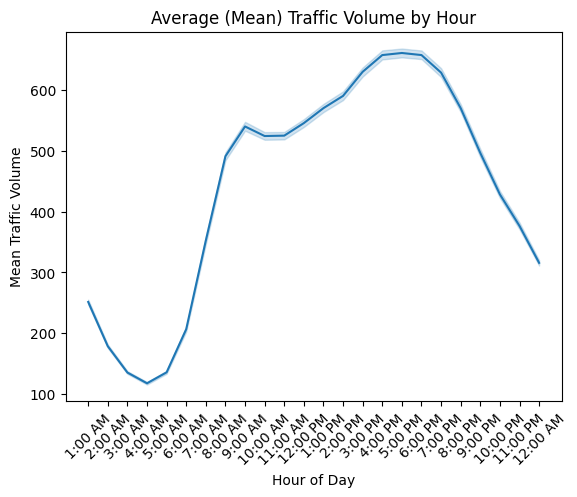

In [0]:
sns.lineplot(
  data=df, x="hour_start", y="traffic_volume",
  estimator = np.mean
)

plt.title("Average (Mean) Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Traffic Volume")

plt.xticks(rotation=45)
plt.show()

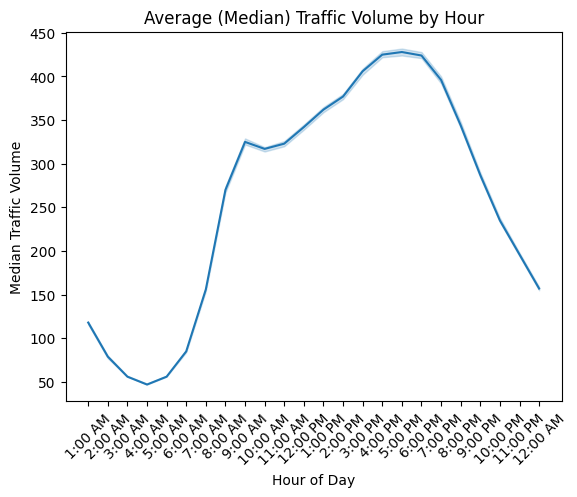

In [0]:
sns.lineplot(
  data=df, x="hour_start", y="traffic_volume",
  estimator = np.median
)

plt.title("Average (Median) Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Median Traffic Volume")

plt.xticks(rotation=45)
plt.show()

### Hourly Traffic Patterns

The hourly traffic analysis reveals strong temporal patterns in vehicle volume throughout the day. Traffic volume tends to significantly increase during commuting windows, particularly during morning and evening rush hours.

These recurring peaks are important because they indicate predictable congestion periods that city transportation planners can target for operational improvements. For example:

- **Dynamic lane management/routing strategies** could be implemented during known congestion windows (e.g., EZPass)
- **Logistic operators and construction workers** may use these insights to better schedule operations during lower traffic periods.

From an analytics perspective, the presence of clear daily cycles confirms that the response (traffic volume) exhibits **significant temporal seasonality**. In the modeling phase , this motivates the engineering of time-based predictive features such as hour-of-day, weekday indicators, and perhaps cyclical transformations to efficiently capture these effects. 

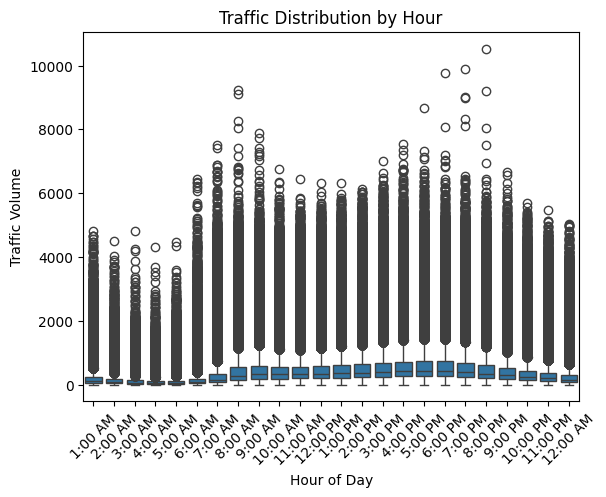

In [0]:
sns.boxplot(
    data=df,
    x="hour_start",
    y="traffic_volume"
)

plt.xlabel("Hour of Day")
plt.ylabel("Traffic Volume")
plt.title("Traffic Distribution by Hour")

plt.xticks(rotation=45)
plt.show()

### Distribution of Traffic Volume by Hour

The hourly box plot highlights the variability of traffic volumes throughout the day. While the mean and median traffic volume line plots provide an overal trend, the box plot reveals how widely traffic volumes fluctuate within each hour. It also confirms that the traffic volume counts are extremely right skewed.

This variability is important to understand for traffic management endeavors because roadway congestion is not only determined by the average vehicular counts but also by **traffic volatility**. Hours with high variability might indicate unstable traffic conditions, where additional disturbances such as accidents or bad weather conditions could quickly lead to increased congestion.

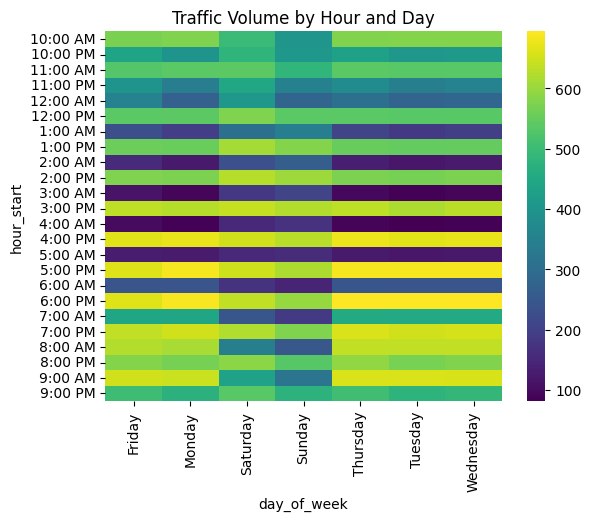

In [0]:
pivot = df.pivot_table(
    values="traffic_volume",
    index="hour_start",
    columns="day_of_week",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="viridis")
plt.title("Traffic Volume by Hour and Day")
plt.show()

/home/spark-a114b560-b7db-4b0e-b6e6-2e/.ipykernel/14613/command-7125230341596523-1284531401:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


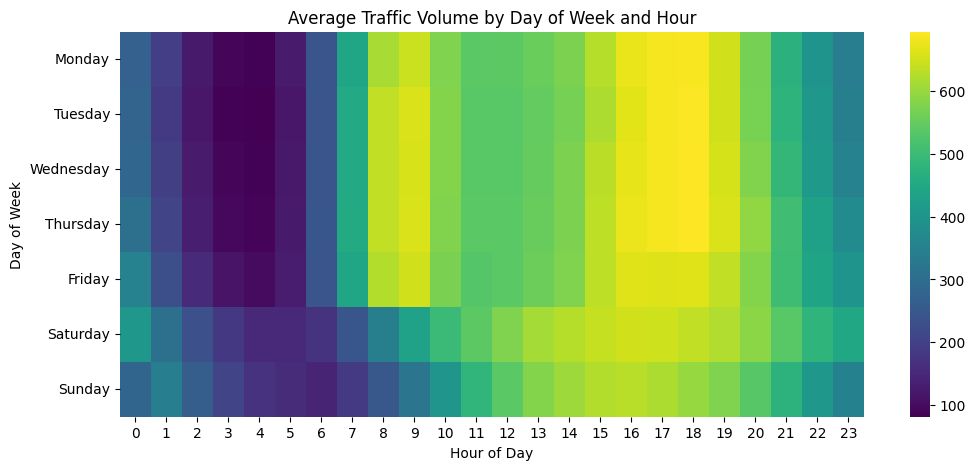

In [0]:
pivot = df.pivot_table(
    values="traffic_volume",
    index="day_of_week",
    columns="hour",
    aggfunc="mean"
)

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = pivot.reindex(day_order)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, cmap="viridis")
plt.title("Average Traffic Volume by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

### Traffic Intensity Across Hours and Days

The heatmap visualizations provide a compact representation of traffic intensity across hours of the day and day of the week in NYC.

This visualization highlights consistent patterns such as:

- Higher traffic volumes during weekday commuting hours
- Lower traffic acactivityctivity during late-night/early-morning periods
- Different traffic patterns between days earlier in the week (namely Monday, Tuesday, Wednesday, and Thursday) vs later days (Friday, Saturday, and Sunday).

These patterns are critical in understanding the behavioral dynamics of vehicular mobility withn the city. For example, weekday traffic patterns are typically influenced by work commutes, while weekend traffic may be driven by leisure.

In [0]:
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

df["day_of_week"] = pd.Categorical(
    df["day_of_week"],
    categories=day_order,
    ordered=True
)

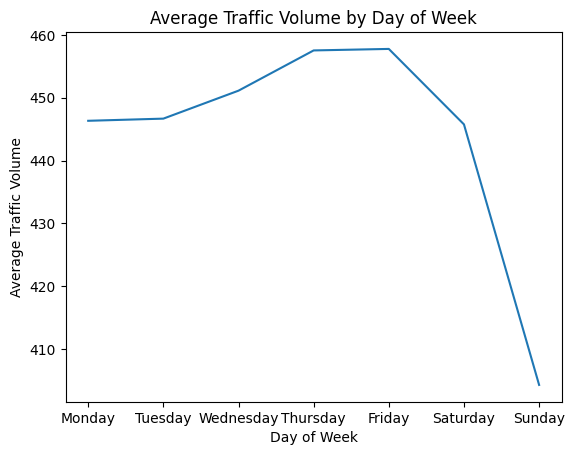

In [0]:
sns.lineplot(
    data=df,
    x="day_of_week",
    y="traffic_volume",
    estimator="mean",
    errorbar=None
)

plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Traffic Volume")

plt.show()

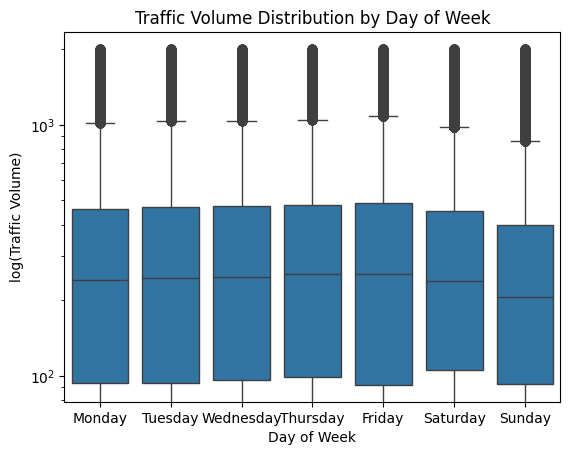

In [0]:
sns.boxplot(
    data=df.loc[df.traffic_volume < 2000],
    x="day_of_week",
    y="traffic_volume"
)
plt.yscale("log")
plt.title("Traffic Volume Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("log(Traffic Volume)")
plt.show()

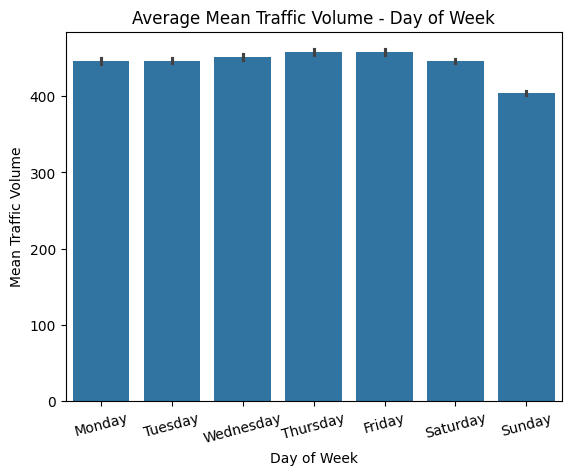

In [0]:
sns.barplot(
    data=df,
    x="day_of_week",
    y="traffic_volume",
    estimator=np.mean
)

plt.ylabel('Mean Traffic Volume')
plt.xlabel('Day of Week')
plt.xticks(rotation=15)
plt.title ("Average Mean Traffic Volume - Day of Week");

### Weekly Traffic Behavior

Analyzing traffic volume by day of the week confirms differences between weekday and weekend traffic behavior.

Weekday traffic tends to be more structured and predictable due to commuting patterns associated with work and school schedules. In contrast, weekend traffic is more variable, as leisurely travel and events are more stochastic.

Understanding these differences has practical implications for city operations:

- **Road maintenace scheduling** may be prioritized during lower traffic periods over the weekends.
- **Construction planning** can minimize city-wide traffic disruptions by targeting these lower-roadway demand days.

These insights support data-driven planning decisions across NYC transportation agencies.

/home/spark-a114b560-b7db-4b0e-b6e6-2e/.ipykernel/14613/command-7125230341596514-2063211571:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


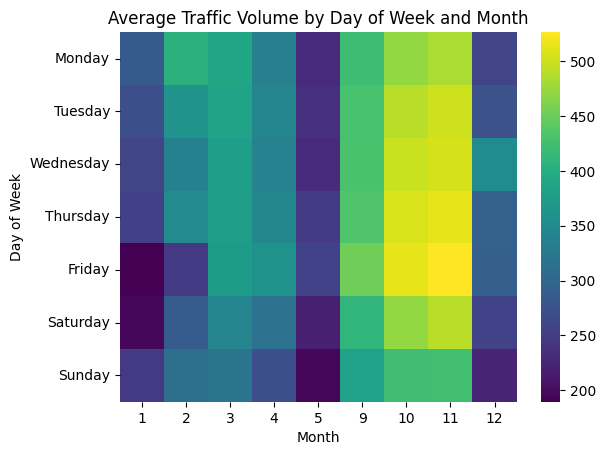

In [0]:
order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

pivot = df.pivot_table(
    values="traffic_volume",
    index="day_of_week",
    columns="month",
    aggfunc="mean"
)

pivot = pivot.loc[order]

sns.heatmap(pivot, cmap="viridis")

plt.title("Average Traffic Volume by Day of Week and Month")
plt.xlabel("Month")
plt.ylabel("Day of Week")
plt.show()

### Traffic Volume by Day of Week and Month

This heatmap extrextendsends the weekly traffic analysis by highlighting how traffic volumes change across both **day-of-week** and **month**. This visualization helps reveal whether the weekly patterns hold throughout the year or shift seasonally.

Insights:
- Certain months (namely October and November) appear to exhibit consistently higher traffic volumes across most days of the week.
- Across every month, weekday traffic remains stronger than weekend traffic.

From a business and operational perspective, this heatmap helps traffic workers move beyond short-term traffic monitoring and recognize **recurring seasonal demand patterns**. This enables:

- **Traffic ignal timing strategies** may need to be adjusted not only by hour and weekday, but also by time of year.
- **Road maintenance and construction planning** can be scheduled during relatively lower-volume months or day/month combinations to minimize disruptions.
- **Traffic enforcement resources** can be allocated more effectively during historically high-demand seasonal periods.
- **Forecasting models** may benefit from this insight because it suggests that month-based seasonality can be incorporated effectively as an explanatory feature, rather than just simply assuming traffic behavior is constant throughout the year.




In [0]:
df.head()

,segment_id,roadway__name,from,to,direction,date,hour,hour_start,day_of_week,weekday,month,is_weekend,timestamp,traffic_volume
0,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-09,1,1:00 AM,Monday,0,1,False,2012-01-09 01:00:00,20.0
1,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-10,1,1:00 AM,Tuesday,1,1,False,2012-01-10 01:00:00,21.0
2,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-11,1,1:00 AM,Wednesday,2,1,False,2012-01-11 01:00:00,27.0
3,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-12,1,1:00 AM,Thursday,3,1,False,2012-01-12 01:00:00,22.0
4,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-13,1,1:00 AM,Friday,4,1,False,2012-01-13 01:00:00,31.0


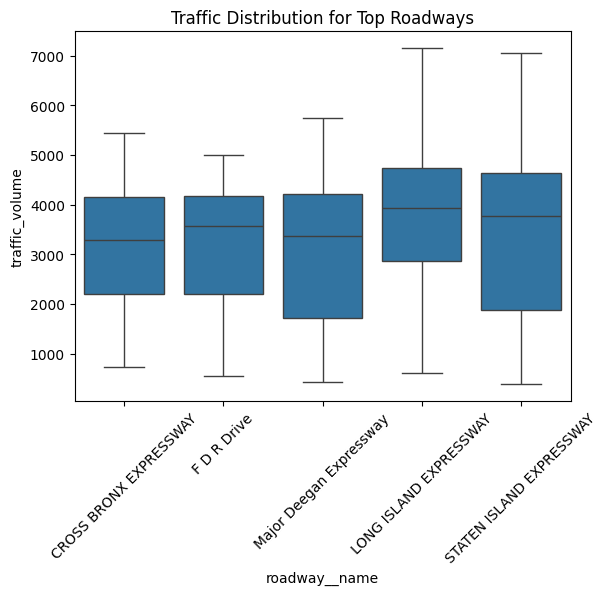

In [0]:
top_roads = (
    df.groupby("roadway__name")["traffic_volume"]
    .mean()
    .nlargest(5)
    .index
)

sns.boxplot(
    data=df[df["roadway__name"].isin(top_roads)],
    x="roadway__name",
    y="traffic_volume"
)

plt.xticks(rotation=45)
plt.title("Traffic Distribution for Top Roadways")
plt.show()

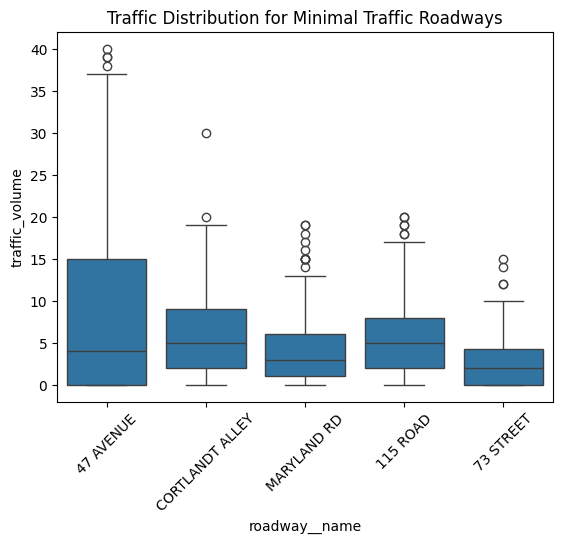

In [0]:
min_traffic_roads = (
    df.groupby("roadway__name")["traffic_volume"]
    .mean()
    .nsmallest(5)
    .index
)

sns.boxplot(
    data=df[df["roadway__name"].isin(min_traffic_roads)],
    x="roadway__name",
    y="traffic_volume"
)

plt.xticks(rotation=45)
plt.title("Traffic Distribution for Minimal Traffic Roadways")
plt.show()

### High vs Low-Traffic Roadways

Comparing traffic distributions across roadway segments allow us to identify and discern consistently high-volume roads and relatively low-demand roads.

High-traffic segments may require:

- Traffic signal optimization improvements and maintenance
- Lane capacity improvements
- Priority monitoring
- Intersection traffic signal redesign

Conversely, low-traffic corridors may present opportunities for alternative roadway infrastructure such as bike lanes.

# Time-Series Specific EDA

In [0]:
ts = (
    df.groupby("timestamp")["traffic_volume"]
    .mean()
    .sort_index()
)
ts = ts.asfreq('h')
ts = ts.interpolate(limit_direction="both") # forward, backward, and interior gaps to ensure no NaNs remain

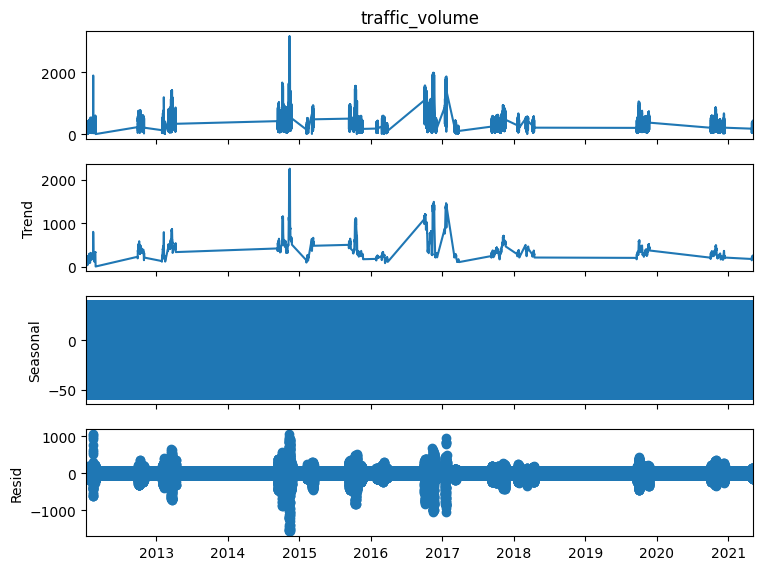

In [0]:
hourly_result = seasonal_decompose(ts, model='additive', period=24)

fig = hourly_result.plot()
fig.set_size_inches(8, 6)

plt.show()

### Time-Series Decomposition

The seasonal decomposition separates traffic volume into three components:

- **Trend:** long-term changes in traffic volume
- **Seasonality:** recurring traffic patterns within a day
- **Residual noise:** irregular fluctuations not explained by time-based patterns

However, because the dataset contains gaps and irregular, non-continuous sensor updates, traditional time-series decomposition techniques and models would be inefficient, as they would be unable to capture all traffic dynamics.

Despite these limitations, the analysis still confirms stong seasonal, cyclical nature of traffic volume, which will inform the design of our more advanced predictive models in the later supervised learning phases of the project.

In [0]:
df.head()

,segment_id,roadway__name,from,to,direction,date,hour,hour_start,day_of_week,weekday,month,is_weekend,timestamp,traffic_volume
0,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-09,1,1:00 AM,Monday,0,1,False,2012-01-09 01:00:00,20.0
1,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-10,1,1:00 AM,Tuesday,1,1,False,2012-01-10 01:00:00,21.0
2,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-11,1,1:00 AM,Wednesday,2,1,False,2012-01-11 01:00:00,27.0
3,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-12,1,1:00 AM,Thursday,3,1,False,2012-01-12 01:00:00,22.0
4,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-13,1,1:00 AM,Friday,4,1,False,2012-01-13 01:00:00,31.0


# Summary of Exploratory Insights

The exploratory analysis reveals several key patterns in the NYC DOT traffic volume dataset:

1. Traffic volumes exhibit strong **daily cyclical patterns**, with clear morning and evening traffic peaks.
2. Traffic behavior varies significantly by **day of the week**, reflectingcommuter-driven demand patterns.
3. Certain roadway segments consistently experience **higher traffic volumes**, suggesting potential congestion hotspots.
4. Traffic distributions are right skewed, which may be indicative of **traffic incidents or even sensor anomalies**



# Extracting and Downloading Cleaned and Properly Structured DataFrame to move into Modeling

In [0]:
import tempfile

temp_path = tempfile.gettempdir() + '/structured_traffic.csv'
df.to_csv(temp_path, index=False)
print(temp_path)

/tmp/structured_traffic.csv


In [0]:
from IPython.display import FileLink
FileLink('/tmp/structured_traffic.csv')

/tmp/structured_traffic.csv